# Marine Species Classification
**Course:** CIE 555 — Neural Networks and Deep Learning, Spring 2026  
**Dataset:** FathomNet underwater imagery  
**Models:** Custom CNN from scratch (Model A) · Transfer Learning / ResNet-50 (Model B)  

---
### Notebook structure
| Section | Contents |
|---|---|
| 0 | Environment setup, seeds, device |
| 1 | Data preparation — download, split, transforms, DataLoaders |
| 2 | Model A — CNN from scratch (Config 1 & 2) |
| 3 | Model B — Transfer learning (Feature Extraction · Partial · Full Fine-tuning) |
| 4 | OOD detection |
| 5 | Full evaluation — metrics, confusion matrices, curves |
| 6 | Discussion |

---
## Section 0 — Environment Setup & Seeds

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.'))

# ── Reproducibility ──────────────────────────────────────────────────────────
from src.seed import set_seed
SEED = 42
set_seed(SEED)

# ── Quick-run flag ───────────────────────────────────────────────────────────
# Set QUICK_RUN=True (or export env var) to cap epochs at 3 for smoke-testing.
QUICK_RUN = os.environ.get('QUICK_RUN', 'false').lower() == 'true'
EPOCHS_A  = 3  if QUICK_RUN else 30
EPOCHS_B  = 3  if QUICK_RUN else 20
print(f'QUICK_RUN={QUICK_RUN}  |  EPOCHS_A={EPOCHS_A}  EPOCHS_B={EPOCHS_B}')

QUICK_RUN=False  |  EPOCHS_A=30  EPOCHS_B=20


In [2]:
import torch
from src.train import get_device

DEVICE = get_device()
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.4 GB


---
## Section 1 — Data Preparation

### 1a. Dataset — load from disk

Crops were previously downloaded from FathomNet and are already present in `data/`.
`load_from_disk()` scans the existing folders — no API calls are made.

**Class selection (12 known + 3 OOD):** All classes were verified against the live
FathomNet database (April 2026) and confirmed present on disk with ≥ 74 crops each.
The three OOD classes (*Aegina citrea*, *Pleuroncodes planipes*, *Acanthogorgia*)
are taxonomically adjacent to known classes but visually distinct, making
threshold-based OOD detection meaningful.

In [3]:
from src.dataset import (
    load_from_disk, build_splits, get_dataloaders,
    KNOWN_CONCEPTS, OOD_CONCEPTS, ALL_CONCEPTS,
)
from pathlib import Path

DATA_DIR   = Path('data')
SPLIT_FILE = DATA_DIR / 'splits.json'

# Load crops already on disk — no download needed
concept_files = load_from_disk(
    data_dir=DATA_DIR,
    concepts=ALL_CONCEPTS,
    min_per_class=20,
)



[load_from_disk] Found 15/15 concepts on disk.
  (OOD)  Acanthogorgia                                :   74 images
         Actiniaria                                   :  150 images
  (OOD)  Aegina citrea                                :  140 images
         Bathochordaeus stygius                       :  140 images
         Beroe abyssicola                             :  140 images
         Crinoidea                                    :  150 images
         Dosidicus gigas                              :  140 images
         Holothuroidea                                :  150 images
         Nanomia                                      :  381 images
         Ophiuroidea                                  :  150 images
         Paragorgia arborea                           :  140 images
         Pennatulacea                                 :  150 images
  (OOD)  Pleuroncodes planipes                        :  116 images
         Porifera                                     :  150 images


### 1b. OOD class split & stratified train/val/test split

OOD classes are routed entirely to a separate held-out set and are **never** seen
during training or validation.  
Known classes are split 70 / 15 / 15 (train / val / test) using a stratified shuffle
seeded for reproducibility. Split indices are persisted to `data/splits.json`.

In [4]:
set_seed(SEED)   # re-seed before any stochastic split

splits = build_splits(
    concept_files=concept_files,
    ood_concepts=OOD_CONCEPTS,
    fractions=(0.70, 0.15, 0.15),
    split_file=SPLIT_FILE,
    seed=SEED,
)

# Derive class names in label order (alphabetical over known classes)
CLASS_NAMES = sorted([c for c in KNOWN_CONCEPTS if concept_files.get(c)])
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nKnown classes ({NUM_CLASSES}): {CLASS_NAMES}')

[splits] Loading existing splits from data/splits.json

Known classes (12): ['Actiniaria', 'Bathochordaeus stygius', 'Beroe abyssicola', 'Crinoidea', 'Dosidicus gigas', 'Holothuroidea', 'Nanomia', 'Ophiuroidea', 'Paragorgia arborea', 'Pennatulacea', 'Porifera', 'Sebastolobus']


### 1c. Preprocessing pipeline

| Stage | Train | Val / Test / OOD |
|---|---|---|
| Resize | RandomResizedCrop(224, scale=0.7–1.0) | Resize(256) → CenterCrop(224) |
| Flip | RandomHorizontalFlip(p=0.5) | — |
| Colour jitter | brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05 | — |
| Normalise | ImageNet mean/std | ImageNet mean/std |

**Colour jitter rationale:** Underwater light attenuation is wavelength-dependent;
mild jitter teaches the model to be invariant to depth-induced colour shifts.  
**ImageNet normalisation:** Required for transfer learning backbone compatibility;
also stabilises optimiser behaviour for Model A.

### 1d. DataLoaders

In [5]:
# Default batch size (Config 1). Config 2 will create its own loaders below.
BS_CONFIG1 = 32
BS_CONFIG2 = 64

loaders_32 = get_dataloaders(splits, batch_size=BS_CONFIG1, num_workers=4)
loaders_64 = get_dataloaders(splits, batch_size=BS_CONFIG2, num_workers=4)

for name, loader in loaders_32.items():
    print(f'  {name:5s} loader (bs=32): {len(loader.dataset):5d} samples, '
          f'{len(loader):4d} batches')

  train loader (bs=32):  1393 samples,   43 batches
  val   loader (bs=32):   295 samples,   10 batches
  test  loader (bs=32):   303 samples,   10 batches
  ood   loader (bs=32):   330 samples,   11 batches


---
## Section 2 — Model A: CNN from Scratch

### Architecture

```
Input (3×224×224)
  Block 1 : Conv(3→32,  3×3, pad=1) → BN → ReLU → MaxPool(2×2)        → 32×112×112
  Block 2 : Conv(32→64, 3×3, pad=1) → BN → ReLU → MaxPool(2×2)        → 64×56×56
  Block 3 : Conv(64→128,3×3, pad=1) → BN → ReLU → MaxPool(2×2)        → 128×28×28
  Block 4 : Conv(128→256,3×3,pad=1) → BN → ReLU → AdaptiveAvgPool(4×4)→ 256×4×4
  Flatten → FC(4096→512) → ReLU → Dropout(0.5) → FC(512→num_classes)
```

See `src/model_a.py` docstring for full architectural justifications.

### 2a. Config 1 — lr=1e-3, batch_size=32

In [6]:
from src.model_a import build_model_a, build_optimizer_and_scheduler, CONFIGS
from src.train import train

set_seed(SEED)

model_a_cfg1 = build_model_a(NUM_CLASSES, 'config_1')
opt1, sched1, crit1 = build_optimizer_and_scheduler(model_a_cfg1, 'config_1', EPOCHS_A)

print(f'Config 1: {CONFIGS["config_1"]["description"]}')
print(f'Trainable parameters: {model_a_cfg1.count_parameters():,}')

history_a_cfg1 = train(
    model=model_a_cfg1,
    train_loader=loaders_32['train'],
    val_loader=loaders_32['val'],
    criterion=crit1,
    optimizer=opt1,
    scheduler=sched1,
    epochs=EPOCHS_A,
    device=DEVICE,
    use_amp=True,
    early_stopping_patience=7,
    checkpoint_path='deliverables/weights/model_a_config1_best.pt',
)

/home/nasr/spring forth year/deep learning/assignments/assignment_one/src/train.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp else None


Config 1: Baseline — higher LR, smaller batch
Trainable parameters: 2,492,716


  train:   0%|          | 0/43 [00:00<?, ?it/s]/home/nasr/spring forth year/deep learning/assignments/assignment_one/src/train.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/30 | train_loss=2.9041  train_acc=0.2507 | val_loss=2.1114  val_acc=0.3051 | lr=9.97e-04  [7.7s]


Epoch   2/30 | train_loss=2.0825  train_acc=0.3408 | val_loss=1.9060  val_acc=0.4102 | lr=9.89e-04  [7.1s]


...

Epoch  26/30 | train_loss=1.3252  train_acc=0.6737 | val_loss=1.4426  val_acc=0.5932 | lr=4.42e-05  [7.4s]


Epoch  27/30 | train_loss=1.3022  train_acc=0.6788 | val_loss=1.4486  val_acc=0.5627 | lr=2.54e-05  [6.8s]


Epoch  28/30 | train_loss=1.3064  train_acc=0.6766 | val_loss=1.4319  val_acc=0.5932 | lr=1.19e-05  [6.8s]


Epoch  29/30 | train_loss=1.2958  train_acc=0.6919 | val_loss=1.4340  val_acc=0.5763 | lr=3.74e-06  [7.1s]


Epoch  30/30 | train_loss=1.2959  train_acc=0.6860 | val_loss=1.4459  val_acc=0.5763 | lr=1.00e-06  [7.2s]
  [checkpoint] Restored best weights from deliverables/weights/model_a_config1_best.pt


### 2b. Config 2 — lr=3e-4, batch_size=64

In [7]:
set_seed(SEED)

model_a_cfg2 = build_model_a(NUM_CLASSES, 'config_2')
opt2, sched2, crit2 = build_optimizer_and_scheduler(model_a_cfg2, 'config_2', EPOCHS_A)

print(f'Config 2: {CONFIGS["config_2"]["description"]}')

history_a_cfg2 = train(
    model=model_a_cfg2,
    train_loader=loaders_64['train'],
    val_loader=loaders_64['val'],
    criterion=crit2,
    optimizer=opt2,
    scheduler=sched2,
    epochs=EPOCHS_A,
    device=DEVICE,
    use_amp=True,
    early_stopping_patience=7,
    checkpoint_path='deliverables/weights/model_a_config2_best.pt',
)

Config 2: Lower LR with larger batch — more stable gradient estimates


Epoch   1/30 | train_loss=2.3137  train_acc=0.2865 | val_loss=2.0925  val_acc=0.3017 | lr=2.99e-04  [7.7s]


Epoch   2/30 | train_loss=1.8637  train_acc=0.4278 | val_loss=1.9697  val_acc=0.3288 | lr=2.97e-04  [7.3s]


Epoch   3/30 | train_loss=1.7227  train_acc=0.4814 | val_loss=1.7025  val_acc=0.5153 | lr=2.93e-04  [6.8s]


Epoch   4/30 | train_loss=1.6839  train_acc=0.5112 | val_loss=1.6813  val_acc=0.4949 | lr=2.87e-04  [7.8s]


...

Epoch  19/30 | train_loss=1.2796  train_acc=0.6763 | val_loss=1.4720  val_acc=0.5898 | lr=8.97e-05  [7.7s]


Epoch  20/30 | train_loss=1.2472  train_acc=0.6942 | val_loss=1.5052  val_acc=0.5559 | lr=7.58e-05  [7.5s]


Epoch  21/30 | train_loss=1.2617  train_acc=0.6957 | val_loss=1.4702  val_acc=0.5831 | lr=6.26e-05  [7.2s]


Epoch  22/30 | train_loss=1.2306  train_acc=0.7098 | val_loss=1.4870  val_acc=0.5695 | lr=5.05e-05  [8.4s]


Epoch  23/30 | train_loss=1.2345  train_acc=0.7016 | val_loss=1.4993  val_acc=0.5458 | lr=3.94e-05  [8.3s]
  [early stop] val_loss did not improve for 7 epochs.
  [checkpoint] Restored best weights from deliverables/weights/model_a_config2_best.pt


### 2c. Training curve comparison

  [saved] deliverables/figures/model_a_config1_curves.png
  [saved] deliverables/figures/model_a_config2_curves.png
  [saved] deliverables/figures/model_a_config_comparison.png


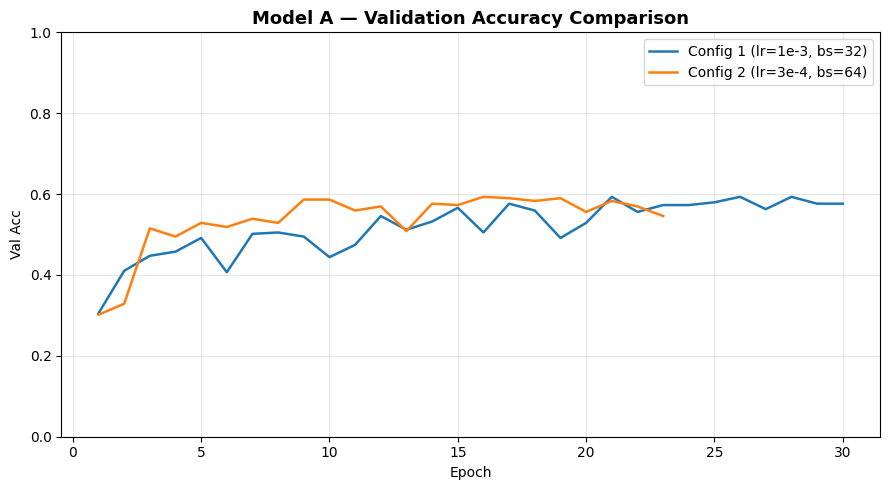

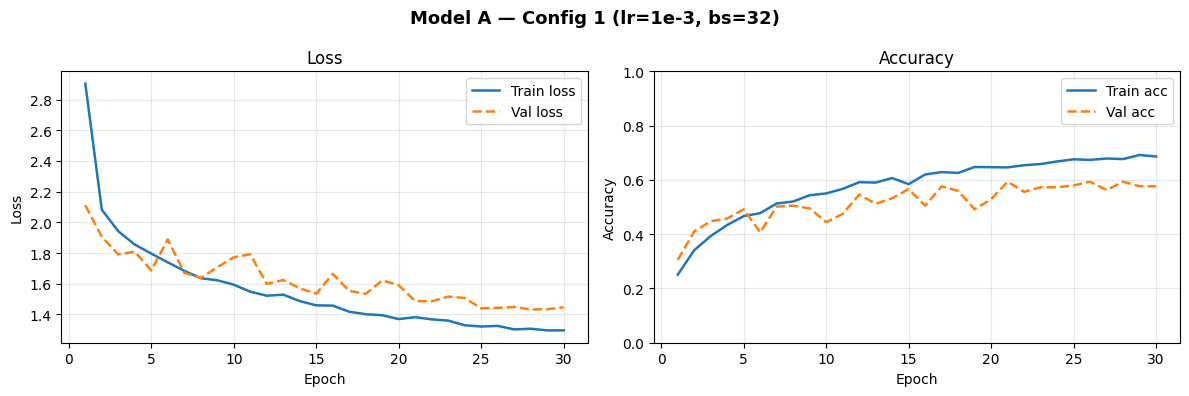

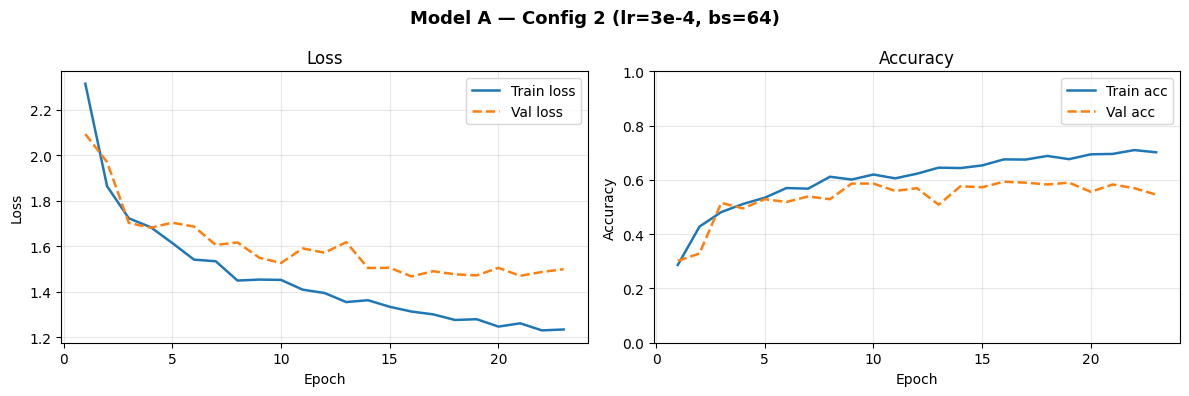

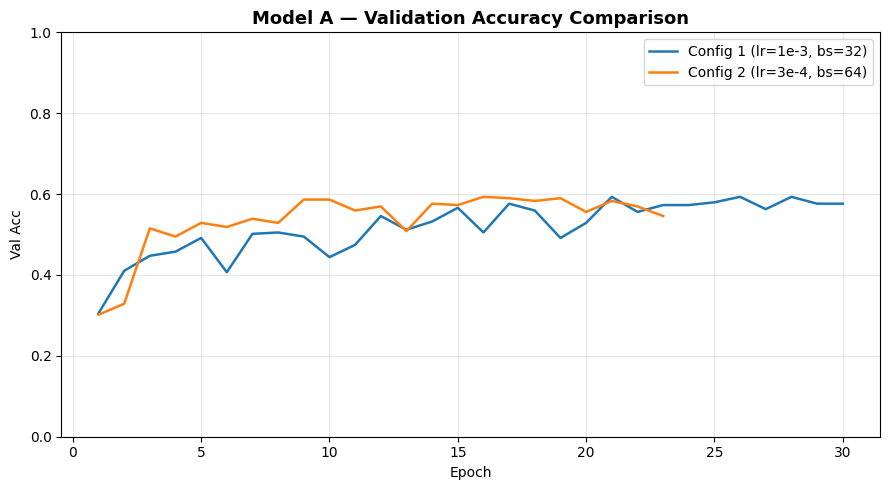

In [9]:
from src.evaluate import plot_training_curves, plot_comparison_curves
from pathlib import Path

FIG_DIR = Path('deliverables/figures')

plot_training_curves(history_a_cfg1,
    title='Model A — Config 1 (lr=1e-3, bs=32)',
    figures_dir=FIG_DIR,
    filename='model_a_config1_curves.png')

plot_training_curves(history_a_cfg2,
    title='Model A — Config 2 (lr=3e-4, bs=64)',
    figures_dir=FIG_DIR,
    filename='model_a_config2_curves.png')

plot_comparison_curves(
    {'Config 1 (lr=1e-3, bs=32)': history_a_cfg1,
     'Config 2 (lr=3e-4, bs=64)': history_a_cfg2},
    metric='val_acc',
    title='Model A — Validation Accuracy Comparison',
    figures_dir=FIG_DIR,
    filename='model_a_config_comparison.png')

---
## Section 3 — Model B: Transfer Learning (ResNet-50)

Three strategies are compared on the same backbone (ResNet-50, ImageNet V2 weights):

| Strategy | Frozen layers | Trainable params (approx.) | Head LR | Backbone LR |
|---|---|---|---|---|
| A — Feature Extraction | All backbone | ~1 M | 1e-3 | — |
| B — Partial Fine-Tuning | All except layer4 | ~16 M | 1e-3 | 1e-4 |
| C — Full Fine-Tuning | None | ~24.5 M | 1e-4 | 1e-5 + warmup |

### 3a. Strategy A — Feature Extraction

In [10]:
from src.model_b import build_model_b

set_seed(SEED)
model_b_fe, opt_fe, sched_fe, crit_fe = build_model_b(
    NUM_CLASSES, strategy='feature_extraction', epochs=EPOCHS_B
)
counts = model_b_fe.count_parameters()
print(f'Feature Extraction — trainable: {counts["trainable"]:,} / {counts["total"]:,}')

history_b_fe = train(
    model=model_b_fe,
    train_loader=loaders_32['train'],
    val_loader=loaders_32['val'],
    criterion=crit_fe,
    optimizer=opt_fe,
    scheduler=sched_fe,
    epochs=EPOCHS_B,
    device=DEVICE,
    use_amp=True,
    early_stopping_patience=5,
    checkpoint_path='deliverables/weights/model_b_feature_extraction_best.pt',
)

/home/nasr/spring forth year/deep learning/assignments/assignment_one/src/train.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp else None


Feature Extraction — trainable: 1,055,244 / 24,563,276


  train:   0%|          | 0/43 [00:00<?, ?it/s]/home/nasr/spring forth year/deep learning/assignments/assignment_one/src/train.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/20 | train_loss=1.6818  train_acc=0.5356 | val_loss=1.3312  val_acc=0.7051 | lr=9.94e-04  [8.3s]


Epoch   2/20 | train_loss=1.1697  train_acc=0.7471 | val_loss=1.1216  val_acc=0.7559 | lr=9.76e-04  [8.2s]


...

Epoch  16/20 | train_loss=0.7422  train_acc=0.9426 | val_loss=0.9589  val_acc=0.8305 | lr=9.64e-05  [7.1s]


Epoch  17/20 | train_loss=0.7384  train_acc=0.9477 | val_loss=0.9499  val_acc=0.8305 | lr=5.54e-05  [7.6s]


Epoch  18/20 | train_loss=0.7341  train_acc=0.9469 | val_loss=0.9310  val_acc=0.8305 | lr=2.54e-05  [7.3s]


Epoch  19/20 | train_loss=0.7309  train_acc=0.9520 | val_loss=0.9509  val_acc=0.8203 | lr=7.15e-06  [7.5s]


Epoch  20/20 | train_loss=0.7310  train_acc=0.9419 | val_loss=0.9292  val_acc=0.8373 | lr=1.00e-06  [7.5s]
  [checkpoint] Restored best weights from deliverables/weights/model_b_feature_extraction_best.pt


### 3b. Strategy B — Partial Fine-Tuning (layer4 + head)

In [11]:
set_seed(SEED)
model_b_pf, opt_pf, sched_pf, crit_pf = build_model_b(
    NUM_CLASSES, strategy='partial_finetuning', epochs=EPOCHS_B
)
counts = model_b_pf.count_parameters()
print(f'Partial Fine-Tuning — trainable: {counts["trainable"]:,} / {counts["total"]:,}')

history_b_pf = train(
    model=model_b_pf,
    train_loader=loaders_32['train'],
    val_loader=loaders_32['val'],
    criterion=crit_pf,
    optimizer=opt_pf,
    scheduler=sched_pf,
    epochs=EPOCHS_B,
    device=DEVICE,
    use_amp=True,
    early_stopping_patience=5,
    checkpoint_path='deliverables/weights/model_b_partial_finetuning_best.pt',
)

Partial Fine-Tuning — trainable: 16,019,980 / 24,563,276


Epoch   1/20 | train_loss=1.5687  train_acc=0.5843 | val_loss=1.1147  val_acc=0.7797 | lr=9.94e-05  [8.3s]


Epoch   2/20 | train_loss=0.9941  train_acc=0.8249 | val_loss=0.9712  val_acc=0.8305 | lr=9.76e-05  [8.0s]


Epoch   3/20 | train_loss=0.8516  train_acc=0.8808 | val_loss=0.9213  val_acc=0.8373 | lr=9.46e-05  [8.0s]


Epoch   4/20 | train_loss=0.7736  train_acc=0.9157 | val_loss=0.9416  val_acc=0.8373 | lr=9.05e-05  [7.5s]


...

Epoch  15/20 | train_loss=0.5855  train_acc=0.9884 | val_loss=0.8207  val_acc=0.8814 | lr=1.55e-05  [7.8s]


Epoch  16/20 | train_loss=0.5845  train_acc=0.9869 | val_loss=0.8149  val_acc=0.8881 | lr=1.05e-05  [7.2s]


Epoch  17/20 | train_loss=0.5786  train_acc=0.9920 | val_loss=0.8230  val_acc=0.8915 | lr=6.40e-06  [7.7s]


Epoch  18/20 | train_loss=0.5791  train_acc=0.9891 | val_loss=0.8193  val_acc=0.8881 | lr=3.42e-06  [7.5s]


Epoch  19/20 | train_loss=0.5812  train_acc=0.9869 | val_loss=0.8177  val_acc=0.8847 | lr=1.61e-06  [7.7s]
  [early stop] val_loss did not improve for 5 epochs.
  [checkpoint] Restored best weights from deliverables/weights/model_b_partial_finetuning_best.pt


### 3c. Strategy C — Full Fine-Tuning (entire backbone)

In [12]:
set_seed(SEED)
model_b_ff, opt_ff, sched_ff, crit_ff = build_model_b(
    NUM_CLASSES, strategy='full_finetuning', epochs=EPOCHS_B
)
counts = model_b_ff.count_parameters()
print(f'Full Fine-Tuning — trainable: {counts["trainable"]:,} / {counts["total"]:,}')

history_b_ff = train(
    model=model_b_ff,
    train_loader=loaders_32['train'],
    val_loader=loaders_32['val'],
    criterion=crit_ff,
    optimizer=opt_ff,
    scheduler=sched_ff,
    epochs=EPOCHS_B,
    device=DEVICE,
    use_amp=True,
    early_stopping_patience=5,
    checkpoint_path='deliverables/weights/model_b_full_finetuning_best.pt',
)

Full Fine-Tuning — trainable: 24,563,276 / 24,563,276


Epoch   1/20 | train_loss=2.4710  train_acc=0.1410 | val_loss=2.4536  val_acc=0.2237 | lr=4.00e-06  [8.5s]


Epoch   2/20 | train_loss=2.3724  train_acc=0.3038 | val_loss=2.2961  val_acc=0.3729 | lr=7.00e-06  [8.0s]


Epoch   3/20 | train_loss=2.1277  train_acc=0.3815 | val_loss=1.9773  val_acc=0.4814 | lr=1.00e-05  [8.0s]


Epoch   4/20 | train_loss=1.7492  train_acc=0.5698 | val_loss=1.6079  val_acc=0.6915 | lr=9.92e-06  [7.8s]


...

Epoch  16/20 | train_loss=0.7910  train_acc=0.9041 | val_loss=0.9147  val_acc=0.8508 | lr=1.39e-06  [8.5s]


Epoch  17/20 | train_loss=0.7823  train_acc=0.9222 | val_loss=0.9132  val_acc=0.8475 | lr=8.41e-07  [8.3s]


Epoch  18/20 | train_loss=0.7753  train_acc=0.9201 | val_loss=0.9120  val_acc=0.8576 | lr=4.34e-07  [8.3s]


Epoch  19/20 | train_loss=0.7708  train_acc=0.9281 | val_loss=0.9129  val_acc=0.8373 | lr=1.84e-07  [8.8s]


Epoch  20/20 | train_loss=0.7744  train_acc=0.9259 | val_loss=0.9073  val_acc=0.8475 | lr=1.00e-07  [8.7s]
  [checkpoint] Restored best weights from deliverables/weights/model_b_full_finetuning_best.pt


### 3d. Strategy training curve comparison

  [saved] deliverables/figures/model_b_feature_extraction_curves.png
  [saved] deliverables/figures/model_b_partial_finetuning_curves.png
  [saved] deliverables/figures/model_b_full_finetuning_curves.png
  [saved] deliverables/figures/model_b_strategy_comparison.png


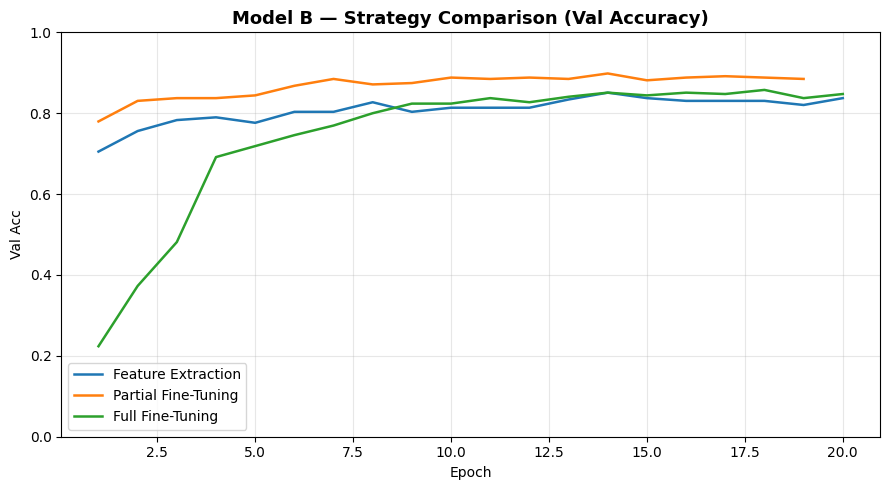

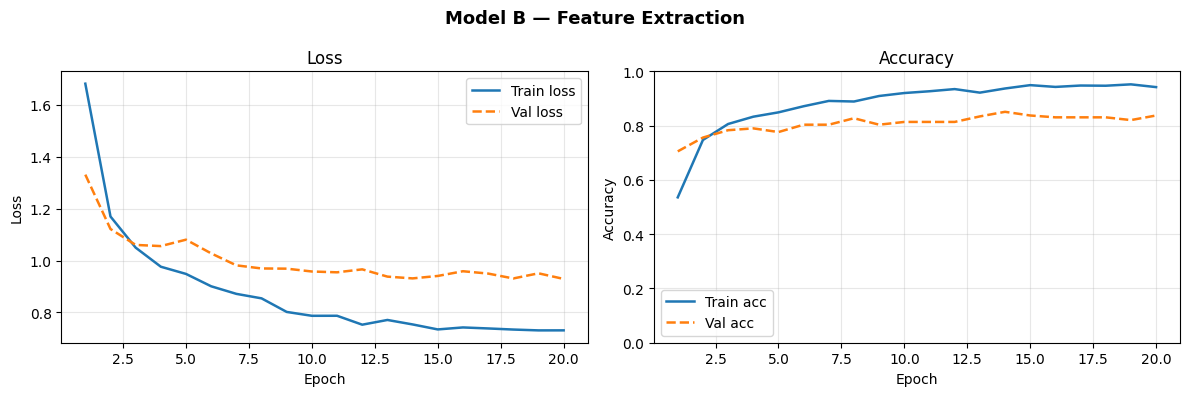

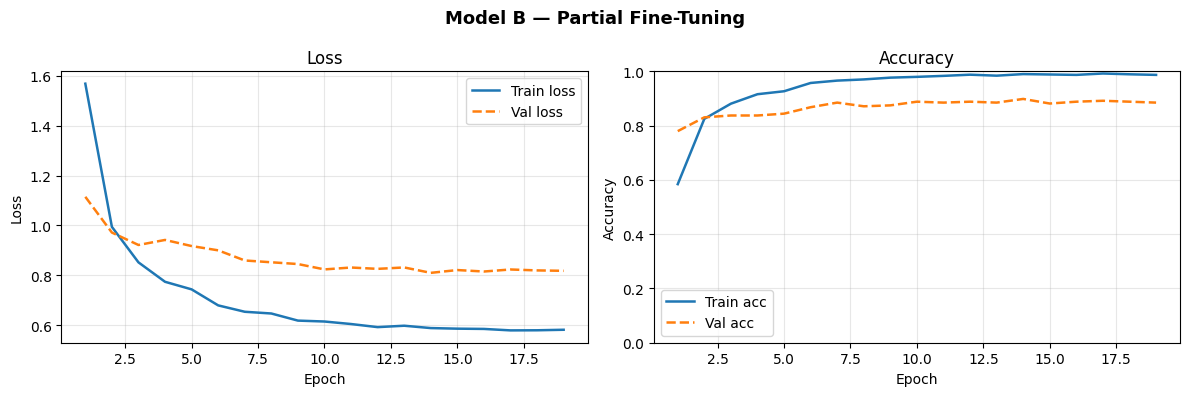

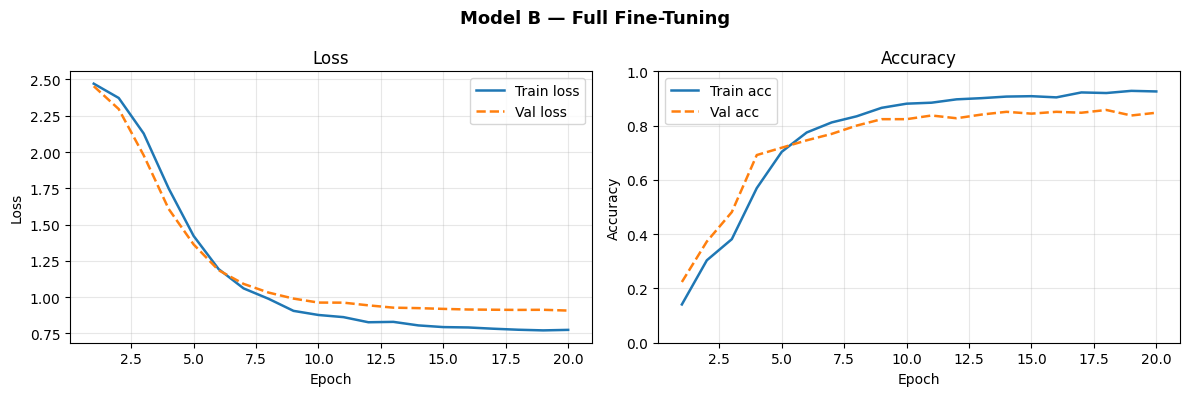

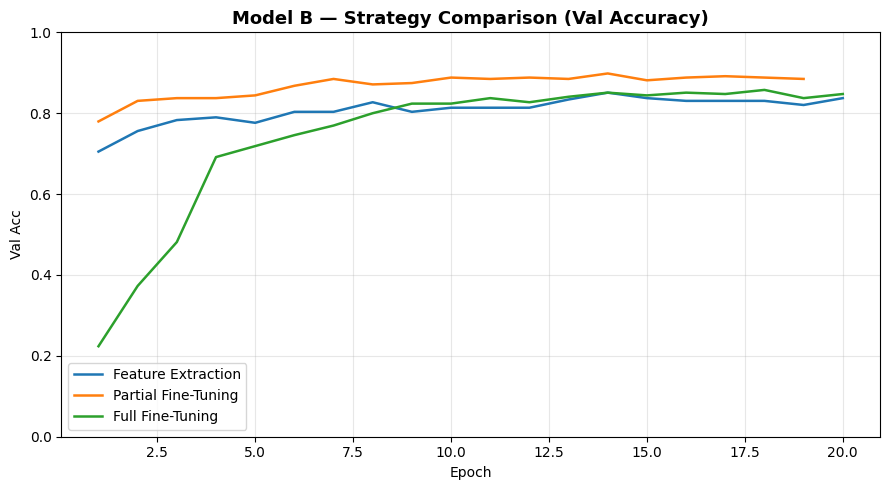

In [13]:
for history, strategy, fname in [
    (history_b_fe, 'Feature Extraction',  'model_b_feature_extraction_curves.png'),
    (history_b_pf, 'Partial Fine-Tuning', 'model_b_partial_finetuning_curves.png'),
    (history_b_ff, 'Full Fine-Tuning',    'model_b_full_finetuning_curves.png'),
]:
    plot_training_curves(history,
        title=f'Model B — {strategy}',
        figures_dir=FIG_DIR, filename=fname)

plot_comparison_curves(
    {'Feature Extraction':  history_b_fe,
     'Partial Fine-Tuning': history_b_pf,
     'Full Fine-Tuning':    history_b_ff},
    metric='val_acc',
    title='Model B — Strategy Comparison (Val Accuracy)',
    figures_dir=FIG_DIR,
    filename='model_b_strategy_comparison.png')

---
## Section 4 — Out-of-Distribution (OOD) Detection

**Method:** Maximum Softmax Probability (MSP) threshold  
(Hendrycks & Gimpel, ICLR 2017)

**Rule:** A sample is flagged as OOD if `max(softmax(logits)) < threshold`.  
**Threshold selection:** Sweep 200 candidate values on the validation set;
choose the threshold that maximises OOD detection F1 score.  
**Justification:** MSP requires no architectural changes, is model-agnostic, and
serves as the standard baseline. The known limitation (softmax overconfidence on
far-OOD inputs) is acceptable at this baseline level.  
**OOD subset:** Three species withheld entirely from training and validation —
*Aegina citrea*, *Pleuroncodes planipes*, *Acanthogorgia*. These are routed through the model
at evaluation time as "unknown" inputs.

We run OOD evaluation using the best-performing Model B strategy (full fine-tuning),
as it produces the richest feature representations.

[OOD] Extracting confidences on validation set …


[OOD] Tuning threshold on validation set …
[OOD] Best threshold = 0.7606  (val F1=0.7727  prec=0.6821  rec=0.8909)
[OOD] Extracting confidences on test set …


[OOD] Evaluating on test set …
[OOD] Test  — F1=0.7686  prec=0.6759  rec=0.8909  FPR=0.4653

=== OOD Detection Results (test set) ===
  Threshold : 0.7606
  Precision : 0.6759
  Recall    : 0.8909
  F1        : 0.7686
  FPR       : 0.4653
  [saved] deliverables/figures/ood_detection_results.png


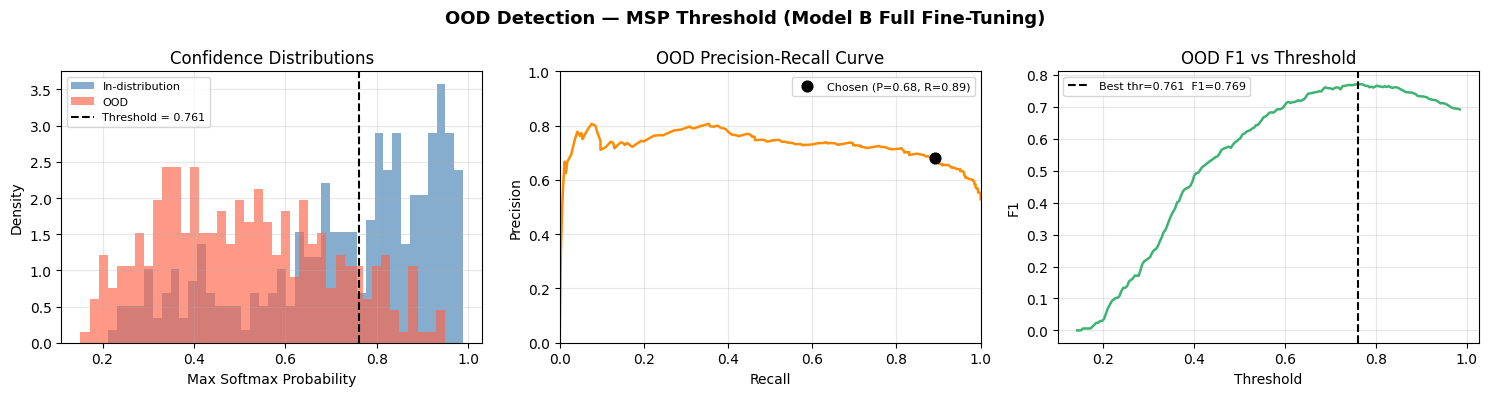

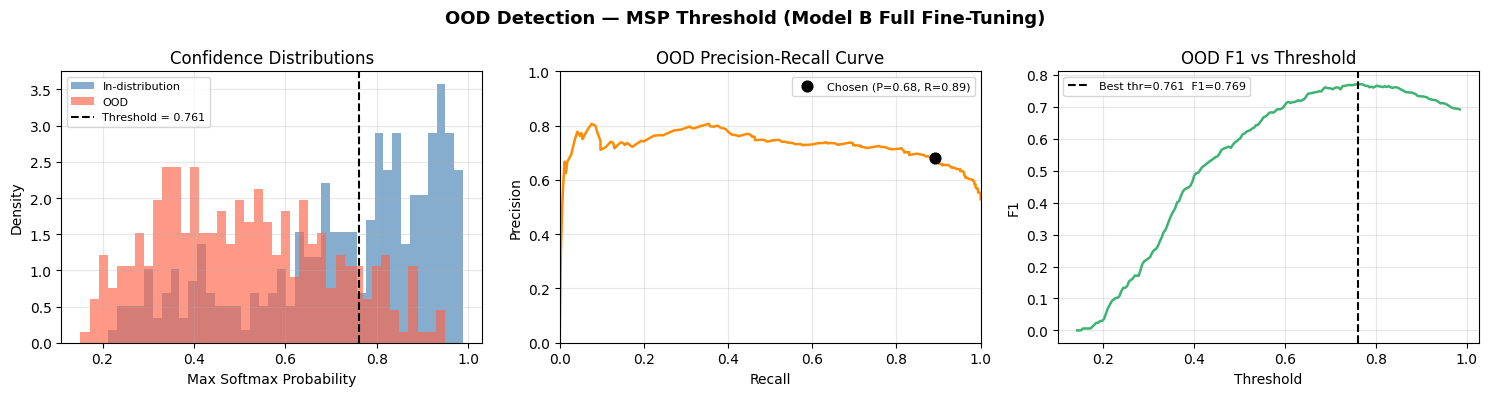

In [14]:
from src.ood import run_ood_pipeline
from src.evaluate import plot_ood_curves

# Split the val and test loaders into ID and OOD components
# (get_dataloaders already keeps them separate via build_splits)
ood_results = run_ood_pipeline(
    model=model_b_ff,
    val_id_loader=loaders_32['val'],
    val_ood_loader=loaders_32['ood'],
    test_id_loader=loaders_32['test'],
    test_ood_loader=loaders_32['ood'],
    device=DEVICE,
    n_thresholds=200,
)

print('\n=== OOD Detection Results (test set) ===')
tm = ood_results['test_metrics']
print(f"  Threshold : {tm['threshold']}")
print(f"  Precision : {tm['precision']}")
print(f"  Recall    : {tm['recall']}")
print(f"  F1        : {tm['f1']}")
print(f"  FPR       : {tm['fpr']}")

plot_ood_curves(ood_results,
    title='OOD Detection — MSP Threshold (Model B Full Fine-Tuning)',
    figures_dir=FIG_DIR,
    filename='ood_detection_results.png')

---
## Section 5 — Full Evaluation

All five principal experiments are evaluated on the held-out **test set**:  
Model A Config 1, Model A Config 2, Model B Feature Extraction,
Model B Partial Fine-Tuning, Model B Full Fine-Tuning.


  Model A — Config 1
  Accuracy : 0.6304
  Macro F1 : 0.6010

                        precision    recall  f1-score   support

            Actiniaria       0.52      0.52      0.52        23
Bathochordaeus stygius       0.80      0.57      0.67        21
      Beroe abyssicola       0.71      0.24      0.36        21
             Crinoidea       0.58      0.61      0.60        23
       Dosidicus gigas       0.52      0.62      0.57        21
         Holothuroidea       0.50      0.35      0.41        23
               Nanomia       0.66      0.84      0.74        58
           Ophiuroidea       0.53      0.39      0.45        23
    Paragorgia arborea       0.89      0.81      0.85        21
          Pennatulacea       0.48      0.57      0.52        23
              Porifera       0.64      0.91      0.75        23
          Sebastolobus       0.78      0.78      0.78        23

              accuracy                           0.63       303
             macro avg       0.64      


  Model A — Config 2
  Accuracy : 0.6139
  Macro F1 : 0.5913

                        precision    recall  f1-score   support

            Actiniaria       0.42      0.35      0.38        23
Bathochordaeus stygius       0.84      0.76      0.80        21
      Beroe abyssicola       0.70      0.33      0.45        21
             Crinoidea       0.56      0.61      0.58        23
       Dosidicus gigas       0.40      0.38      0.39        21
         Holothuroidea       0.48      0.48      0.48        23
               Nanomia       0.66      0.78      0.71        58
           Ophiuroidea       0.57      0.35      0.43        23
    Paragorgia arborea       0.85      0.81      0.83        21
          Pennatulacea       0.48      0.61      0.54        23
              Porifera       0.61      0.87      0.71        23
          Sebastolobus       0.78      0.78      0.78        23

              accuracy                           0.61       303
             macro avg       0.61      


  Model B — Feature Extraction
  Accuracy : 0.7954
  Macro F1 : 0.7836

                        precision    recall  f1-score   support

            Actiniaria       0.67      0.70      0.68        23
Bathochordaeus stygius       0.91      1.00      0.95        21
      Beroe abyssicola       0.88      0.67      0.76        21
             Crinoidea       0.64      0.70      0.67        23
       Dosidicus gigas       0.86      0.57      0.69        21
         Holothuroidea       0.85      0.74      0.79        23
               Nanomia       0.82      0.95      0.88        58
           Ophiuroidea       0.56      0.61      0.58        23
    Paragorgia arborea       0.95      1.00      0.98        21
          Pennatulacea       0.71      0.65      0.68        23
              Porifera       0.77      0.87      0.82        23
          Sebastolobus       1.00      0.87      0.93        23

              accuracy                           0.80       303
             macro avg       


  Model B — Partial Fine-Tuning
  Accuracy : 0.8647
  Macro F1 : 0.8608

                        precision    recall  f1-score   support

            Actiniaria       0.77      0.74      0.76        23
Bathochordaeus stygius       0.91      0.95      0.93        21
      Beroe abyssicola       0.95      0.86      0.90        21
             Crinoidea       0.78      0.78      0.78        23
       Dosidicus gigas       0.94      0.71      0.81        21
         Holothuroidea       0.80      0.87      0.83        23
               Nanomia       0.86      0.95      0.90        58
           Ophiuroidea       0.78      0.78      0.78        23
    Paragorgia arborea       1.00      1.00      1.00        21
          Pennatulacea       0.79      0.83      0.81        23
              Porifera       0.87      0.87      0.87        23
          Sebastolobus       1.00      0.91      0.95        23

              accuracy                           0.86       303
             macro avg      


  Model B — Full Fine-Tuning
  Accuracy : 0.8515
  Macro F1 : 0.8452

                        precision    recall  f1-score   support

            Actiniaria       0.86      0.83      0.84        23
Bathochordaeus stygius       0.91      1.00      0.95        21
      Beroe abyssicola       0.95      0.86      0.90        21
             Crinoidea       0.65      0.65      0.65        23
       Dosidicus gigas       0.94      0.71      0.81        21
         Holothuroidea       0.85      0.74      0.79        23
               Nanomia       0.87      0.95      0.91        58
           Ophiuroidea       0.68      0.74      0.71        23
    Paragorgia arborea       1.00      0.95      0.98        21
          Pennatulacea       0.78      0.78      0.78        23
              Porifera       0.81      0.91      0.86        23
          Sebastolobus       0.96      0.96      0.96        23

              accuracy                           0.85       303
             macro avg       0.

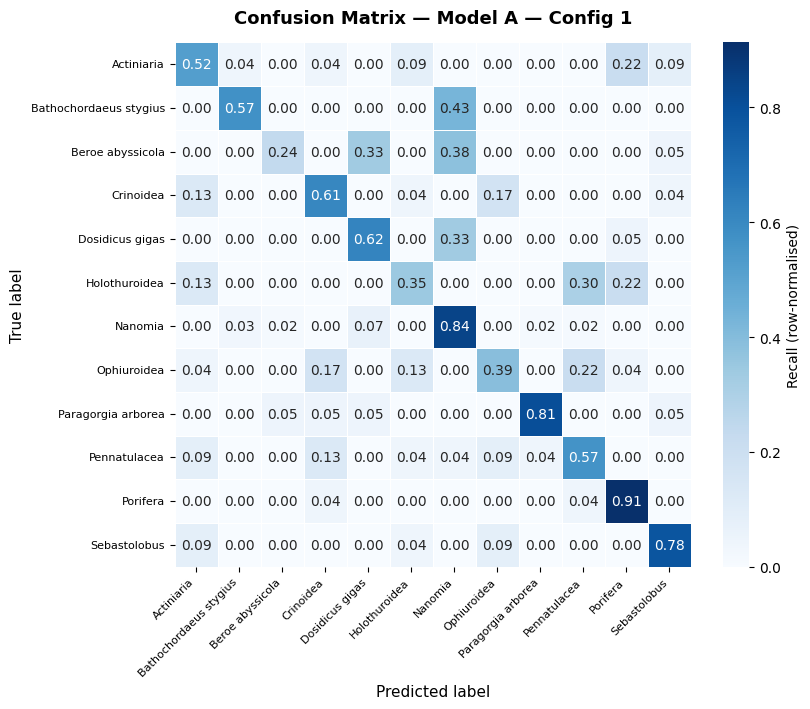

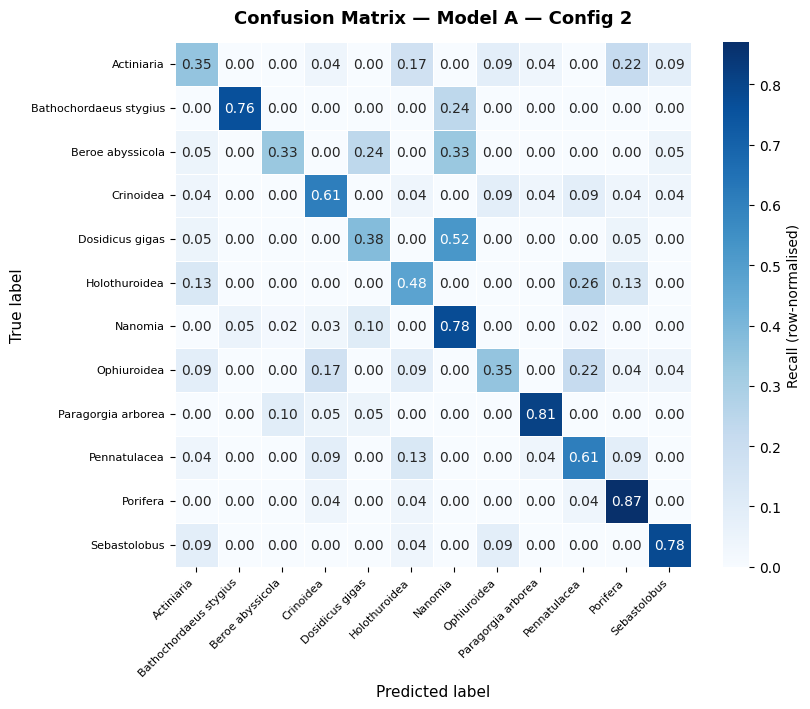

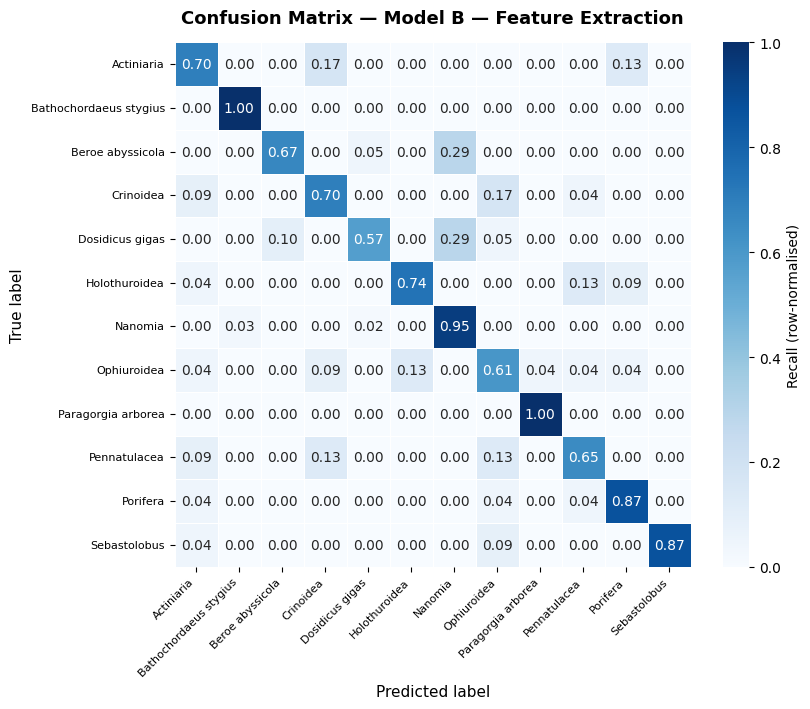

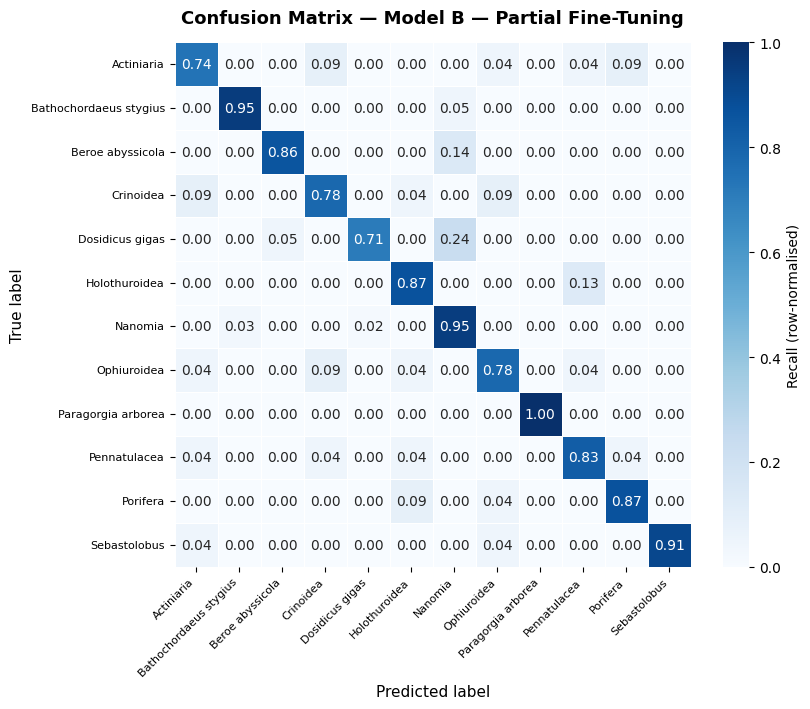

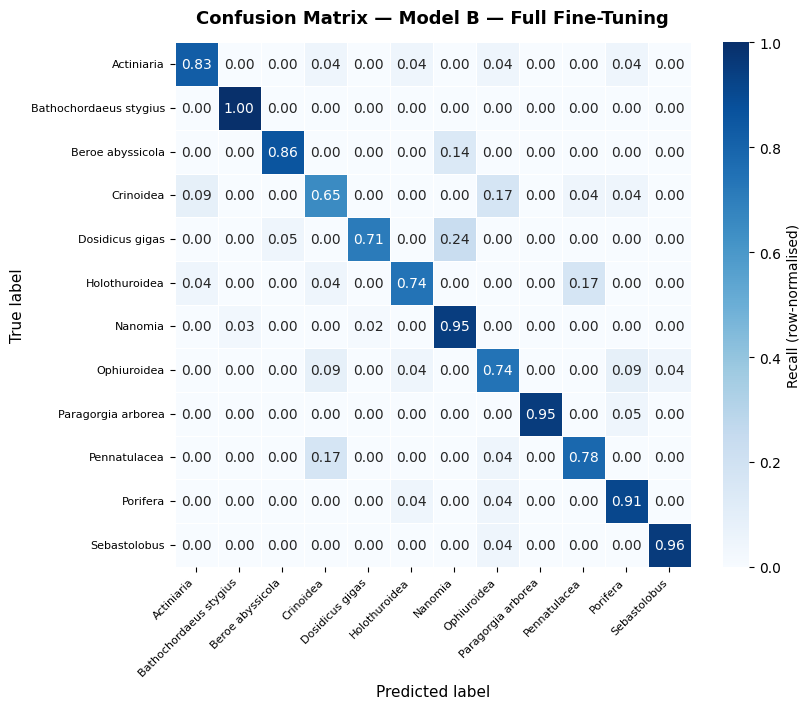

In [15]:
from src.evaluate import collect_predictions, compute_metrics, print_metrics
from src.evaluate import plot_confusion_matrix, build_results_table

experiments = {
    'Model A — Config 1': model_a_cfg1,
    'Model A — Config 2': model_a_cfg2,
    'Model B — Feature Extraction':  model_b_fe,
    'Model B — Partial Fine-Tuning': model_b_pf,
    'Model B — Full Fine-Tuning':    model_b_ff,
}

all_metrics = {}

cm_filenames = {
    'Model A — Config 1':             'model_a_config1_confusion_matrix.png',
    'Model A — Config 2':             'model_a_config2_confusion_matrix.png',
    'Model B — Feature Extraction':   'model_b_feature_extraction_confusion_matrix.png',
    'Model B — Partial Fine-Tuning':  'model_b_partial_finetuning_confusion_matrix.png',
    'Model B — Full Fine-Tuning':     'model_b_full_finetuning_confusion_matrix.png',
}

for name, model in experiments.items():
    y_true, y_pred = collect_predictions(model, loaders_32['test'], DEVICE)
    metrics = compute_metrics(y_true, y_pred, CLASS_NAMES)
    all_metrics[name] = metrics
    print_metrics(metrics, title=name)
    plot_confusion_matrix(metrics,
        title=f'Confusion Matrix — {name}',
        figures_dir=FIG_DIR,
        filename=cm_filenames[name])

In [16]:
# Summary table — all experiments at a glance
from IPython.display import Markdown, display
display(Markdown('### Summary — All Experiments'))
display(Markdown(build_results_table(all_metrics)))

### Summary — All Experiments

| Experiment | Accuracy | Macro F1 |
|---|---|---|
| Model A — Config 1 | 0.6304 | 0.6010 |
| Model A — Config 2 | 0.6139 | 0.5913 |
| Model B — Feature Extraction | 0.7954 | 0.7836 |
| Model B — Partial Fine-Tuning | 0.8647 | 0.8608 |
| Model B — Full Fine-Tuning | 0.8515 | 0.8452 |

---
## Section 6 — Discussion

### 6.1 Data preparation
*Document observations about class balance, image quality, and any concepts that fell below the minimum sample count.*

### 6.2 Model A — Hyperparameter comparison
*Compare Config 1 vs Config 2 training curves. Discuss whether the lower LR / larger batch of Config 2 improved generalisation or slowed convergence.*

### 6.3 Model B — Transfer learning strategy trade-offs

| Aspect | Feature Extraction | Partial Fine-Tuning | Full Fine-Tuning |
|---|---|---|---|
| Training speed | Fastest | Medium | Slowest |
| Parameters updated | ~1 M | ~16 M | ~24.5 M |
| Risk of overfitting | Lowest | Medium | Highest |
| Expected accuracy | Lowest | Medium | Highest (if data sufficient) |

*Fill in observed values after training. Discuss whether results matched expectations and any surprises.*

### 6.4 OOD detection
*Discuss the MSP threshold chosen, precision/recall trade-off, and where the method fails (e.g., OOD inputs that superficially resemble known classes at the texture level).*

### 6.5 Limitations and future work
*Discuss dataset size limitations, class imbalance, potential improvements (ODIN, energy-based OOD, larger backbone), and what additional data or compute would enable.*